In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
!pip install transformers==4.41.2 --no-deps
!pip install tokenizers==0.19.1 --no-deps  # Compatible version

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 96.6 MB/s eta 0:00:00:00:010:01
  Attempting uninstall: transformers
    Found existing installation: transformers 4.53.3
    Uninstalling transformers-4.53.3:
      Successfully uninstalled transformers-4.53.3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 56.2 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.21.2
    Uninstalling tokenizers-0.21.2:
      Successfully uninstalled tokenizers-0.21.2


In [2]:
# Data download and preprocessing for QQP (Quora Question Pairs)

from datasets import load_dataset
from transformers import AutoTokenizer
from pympler import asizeof
from torch.utils.data import DataLoader
from collections import Counter

# Load QQP dataset
qqp_dataset = load_dataset("glue", "qqp")

# Function to filter out invalid labels (if any)
def filter_valid(example):
    return example["label"] != -1

# Filter all QQP splits
qqp_dataset = {
    split: ds.filter(filter_valid) if "test" not in split else ds
    for split, ds in qqp_dataset.items()
}

# Create train dataset
train_dataset = qqp_dataset['train'].shuffle(seed=42)

# Split validation set into two equal halves
validation_full = qqp_dataset['validation'].shuffle(seed=42)
split_point = len(validation_full) // 2

validation_dataset = validation_full.select(range(split_point))
test_dataset = validation_full.select(range(split_point, len(validation_full)))

# Check the dataset structure
print(qqp_dataset)
print(f"\nExample from training set:")
print(qqp_dataset["train"][0])

# Initialize the tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Tokenize function with dynamic padding for question pairs
def tokenize_function(example):
    return tokenizer(
        example["question1"],
        example["question2"],
        padding=False,  # No padding during tokenization
        truncation=True,
        max_length=128
    )

# Tokenize each dataset separately
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_validation = validation_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

# Change dataset format to use "labels" instead of "label"
tokenized_train = tokenized_train.rename_column("label", "labels")
tokenized_validation = tokenized_validation.rename_column("label", "labels")
tokenized_test = tokenized_test.rename_column("label", "labels")

# Set format for PyTorch
tokenized_train.set_format("torch", columns=["input_ids", "token_type_ids", "attention_mask", "labels"])
tokenized_validation.set_format("torch", columns=["input_ids", "token_type_ids", "attention_mask", "labels"])
tokenized_test.set_format("torch", columns=["input_ids", "token_type_ids", "attention_mask", "labels"])

# Print dataset information
print(f"\nTrain dataset size: {len(tokenized_train)}")
print(f"Validation dataset size: {len(tokenized_validation)} (half of original dev set)")
print(f"Test dataset size: {len(tokenized_test)} (other half of original dev set)")

# Attention mask check
print(f"\nAttention mask example: {tokenized_train[0]['attention_mask']}")

# Check the train dataset dtype and size
size_in_bytes = asizeof.asizeof(tokenized_train)
size_in_mb = size_in_bytes / (1024 * 1024)
print(f"\nTotal size of tokenized_train: {size_in_mb:.2f} MB")

# Check label distribution - count of each label (0: not duplicate, 1: duplicate)

# Check label distribution
train_labels = [label.item() for label in tokenized_train["labels"]]
validation_labels = [label.item() for label in tokenized_validation["labels"]]

print(f"\nLabel distribution in train: {Counter(train_labels)}")
print(f"Label distribution in validation: {Counter(validation_labels)}")


# Check data types and shapes
print(f"\nData type and shape information:")
print(f"input_ids - shape: {tokenized_train[0]['input_ids'].shape}, dtype: {tokenized_train[0]['input_ids'].dtype}")
print(f"token_type_ids - shape: {tokenized_train[0]['token_type_ids'].shape}, dtype: {tokenized_train[0]['token_type_ids'].dtype}")
print(f"attention_mask - shape: {tokenized_train[0]['attention_mask'].shape}, dtype: {tokenized_train[0]['attention_mask'].dtype}")
print(f"labels - shape: {tokenized_train[0]['labels'].shape}, dtype: {tokenized_train[0]['labels'].dtype}")

# Check data types of each column
print("\nColumn data types:")
sample = tokenized_train[0]
for key, value in sample.items():
    print(f"Column: {key}, Data Type: {value.dtype}")

README.md: 0.00B [00:00, ?B/s]

qqp/train-00000-of-00001.parquet:   0%|          | 0.00/33.6M [00:00<?, ?B/s]

qqp/validation-00000-of-00001.parquet:   0%|          | 0.00/3.73M [00:00<?, ?B/s]

qqp/test-00000-of-00001.parquet:   0%|          | 0.00/36.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/363846 [00:00<?, ? examples/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/363846 [00:00<?, ? examples/s]

Map:   0%|          | 0/20215 [00:00<?, ? examples/s]

Map:   0%|          | 0/20215 [00:00<?, ? examples/s]


Train dataset size: 363846
Validation dataset size: 20215 (half of original dev set)
Test dataset size: 20215 (other half of original dev set)

Attention mask example: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1])

Total size of tokenized_train: 232.76 MB

Label distribution in train: Counter({0: 229468, 1: 134378})
Label distribution in validation: Counter({0: 12787, 1: 7428})

Data type and shape information:
input_ids - shape: torch.Size([29]), dtype: torch.int64
token_type_ids - shape: torch.Size([29]), dtype: torch.int64
attention_mask - shape: torch.Size([29]), dtype: torch.int64
labels - shape: torch.Size([]), dtype: torch.int64

Column data types:
Column: labels, Data Type: torch.int64
Column: input_ids, Data Type: torch.int64
Column: token_type_ids, Data Type: torch.int64
Column: attention_mask, Data Type: torch.int64


In [7]:
import torch
import torch.nn as nn
import inspect
from transformers import BertConfig, BertForSequenceClassification

class BertForNLI(nn.Module):
    def __init__(self, vocab_size=30522, num_labels=2):
        super().__init__()
        
        # === Custom BERT config (~23M params) ===
        config = BertConfig(
            vocab_size=vocab_size,
            hidden_size=384,
            num_hidden_layers=6,
            num_attention_heads=6,
            intermediate_size=1536,
            hidden_dropout_prob=0.1,
            attention_probs_dropout_prob=0.1,
            max_position_embeddings=512,
            type_vocab_size=2,
            num_labels=num_labels  
        )
        
        # Classification head instead of MLM
        self.model = BertForSequenceClassification(config)
        

    def forward(self, input_ids, attention_mask=None, token_type_ids=None, labels=None):
        """
        Forward pass for NLI (sequence classification).
        Returns logits + loss (if labels are provided).
        """
        outputs = self.model(
            input_ids=input_ids,
            token_type_ids=token_type_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        return outputs.logits, outputs.loss if labels is not None else None

    def configure_optimizers(self, weight_decay, learning_rate, device="cuda", verbose=False):
        """
        AdamW optimizer with weight decay only on weight matrices.
        """
        param_dict = {pn: p for pn, p in self.named_parameters() if p.requires_grad}

        decay_params = [p for n, p in param_dict.items() if p.dim() >= 2]
        nodecay_params = [p for n, p in param_dict.items() if p.dim() < 2]

        optim_groups = [
            {"params": decay_params, "weight_decay": weight_decay},
            {"params": nodecay_params, "weight_decay": 0.0},
        ]

        fused_available = "fused" in inspect.signature(torch.optim.AdamW).parameters
        use_fused = fused_available and "cuda" in device

        if verbose:
            num_decay = sum(p.numel() for p in decay_params)
            num_nodecay = sum(p.numel() for p in nodecay_params)
            print(f"decay params: {len(decay_params)} tensors, {num_decay/1e6:.2f}M params")
            print(f"nodecay params: {len(nodecay_params)} tensors, {num_nodecay/1e6:.2f}M params")
            print(f"Using fused AdamW: {use_fused}")

        optimizer = torch.optim.AdamW(
            optim_groups,
            lr=learning_rate,
            betas=(0.9, 0.999),
            eps=1e-8,
            fused=use_fused
        )
        return optimizer



# Device setup
device = "cuda" if torch.cuda.is_available() else "cpu"

# Set random seeds for reproducibility
torch.manual_seed(1337)
if torch.cuda.is_available():
    torch.cuda.manual_seed(1337)

# Initialize the model
model = BertForNLI(num_labels=2)
model = model.to(device)

total_params = sum(param.numel() for param in model.parameters())
print(f"Total number of parameters: {total_params/1e6}M")


#TF16
torch.set_float32_matmul_precision('high')

Total number of parameters: 22.713986M


In [14]:
import os
import math
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.data import DataLoader
from transformers import DataCollatorWithPadding
from torch.cuda.amp import GradScaler, autocast
from datetime import datetime, timezone

batch_size = 256

data_collator = DataCollatorWithPadding(tokenizer=tokenizer, max_length=128)

train_dataloader = DataLoader(
    tokenized_train,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=data_collator
)
val_dataloader = DataLoader(
    tokenized_validation,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=data_collator
)

# Quick check
print(f"Training batches: {len(train_dataloader)}") 
print(f"Validation (matched) batches: {len(val_dataloader)}")


#---------------------------------------Training hyperparameters---------------------------------
num_epochs = 4
max_steps = num_epochs * len(train_dataloader)   #29440-32, 14720-64
grad_clip = 1.0  # Gradient clipping value
eval_interval = 500  # 262,525
log_interval = 100  # Log loss every 100 steps

# Setup learning rate scheduler
max_lr = 5.5e-4
min_lr = 5.5e-5

warmup_steps = int(0.05 * max_steps)  
plateau = int(0.3 * max_steps)

device = "cuda" if torch.cuda.is_available() else "cpu"



# ---------------------------------cosine learning rate scheduler with warmup------------------------------------------------

def get_lr(it):
    # Linear warm-up
    if it < warmup_steps:
        return max_lr * (it + 1) / warmup_steps
    if it<plateau:
        return max_lr
    # If it > max_steps return min lr
    if it > max_steps:
        return min_lr
    # Cosine decay between warmup and max steps
    decay_ratio = (it - plateau) / (max_steps - plateau)
    assert 0 <= decay_ratio <= 1
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))
    return min_lr + coeff * (max_lr - min_lr)


optimizer = model.configure_optimizers(weight_decay=0.1,learning_rate=max_lr,device=device,verbose=True)

# ---------------------------------------------------------------------------------------------------------

# History tracking for plots
train_losses = []
val_losses = []
val_accs = []
steps_history = []


def evaluate(dataloader, split_name):
    """Evaluation function with cleaner progress display"""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    # Create a progress bar that updates in place
    progress_bar = tqdm(dataloader, desc=f"Evaluating {split_name}",
                        leave=True, position=0,
                        ncols=80,  # Adjust width as needed
                        bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]')

    with torch.no_grad():
        for batch in progress_bar:
            # Move batch to device
            input_ids = batch["input_ids"].to(device)
            segment_ids = batch["token_type_ids"].to(device)
            labels = batch["labels"].to(device)
            attention_mask = batch["attention_mask"].to(device).bool()

            # # Forward pass
            # logits, loss = model(input_ids, segment_ids, labels, attention_mask=attention_mask)
            # Forward pass
            with torch.autocast(device_type=device, dtype=torch.bfloat16):
                logits, loss = model(
                    input_ids=input_ids,
                    token_type_ids=segment_ids,
                    attention_mask=attention_mask,
                    labels=labels
                )

            # Get predictions
            preds = torch.argmax(logits, dim=-1)

            # Track predictions and labels
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            total_loss += loss.item()

            # Update progress bar with current accuracy
            current_acc = (preds == labels).sum().item() / labels.size(0)
            progress_bar.set_postfix(batch_acc=f"{current_acc:.4f}",
                                    loss=f"{loss.item():.4f}",
                                    refresh=False)

    # Calculate metrics
    accuracy = correct / total
    avg_loss = total_loss / len(dataloader)

    # Print final metrics
    print(f"\n{split_name} Results | Loss: {avg_loss:.4f} | Accuracy: {accuracy:.4f}")

    return {
        "loss": avg_loss,
        "accuracy": accuracy
    }

def plot_training_history():
    """Plot training and validation metrics."""
    plt.figure(figsize=(12, 8))

    # Plot losses
    plt.subplot(2, 1, 1)
    plt.plot(steps_history, train_losses, label='Train Loss')
    plt.plot(steps_history, val_losses, label='Val Loss')
    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)

    # Plot accuracies
    plt.subplot(2, 1, 2)
    plt.plot(steps_history, val_accs, label='Val Accuracy')
    plt.xlabel('Steps')
    plt.ylabel('Accuracy')
    plt.title('Validation Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig('training_history.png')
    plt.close()
    print("Training history plot saved to 'training_history.png'")

# Main training function
def train():
    global_step = 0
    best_val_acc = 0.0
    start_time = time.time()  # Start timer


    # Initialize history tracking
    global train_losses, val_losses 
    global val_accs, steps_history

    # Main training loop
    for epoch in range(num_epochs):
        print(f"Starting epoch {epoch+1}/{num_epochs}")
        model.train()

        # Track metrics for this epoch
        epoch_losses = []

        # Use standard PyTorch dataloader iteration
        progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}")
        for batch in progress_bar:
            if global_step >= max_steps:
                break

            t0 = time.time()

            # Get batch data and move to device
            input_ids = batch["input_ids"].to(device)
            segment_ids = batch["token_type_ids"].to(device)
            labels = batch["labels"].to(device)
            attention_mask = batch["attention_mask"].to(device).bool()


            # Zero gradients
            optimizer.zero_grad()

            # # Forward pass
            # logits, loss = model(input_ids, segment_ids, labels, attention_mask=attention_mask)

            #-------------------------------------autocast---------------------------------
            # with torch.autocast(device_type=device,dtype=torch.bfloat16):
            #         logits,loss = model(input_ids, segment_ids, labels, attention_mask=attention_mask)

            with torch.autocast(device_type=device, dtype=torch.bfloat16):
                logits, loss = model(
                    input_ids=input_ids,
                    token_type_ids=segment_ids,
                    attention_mask=attention_mask,
                    labels=labels
                )

            #------------------------------------------------------------------------------

            # Backward pass
            loss.backward()

            # Gradient clipping
            norm = torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            # Update learning rate
            lr = get_lr(global_step)
            for param_group in optimizer.param_groups:
                param_group['lr'] = lr

            # Update weights
            optimizer.step()

            # Track epoch loss
            current_loss = loss.item()
            epoch_losses.append(current_loss)

            # Synchronize CUDA for accurate timing
            if torch.cuda.is_available():
                torch.cuda.synchronize()

            # Calculate speed metrics
            t1 = time.time()
            dt = (t1 - t0)

            # Tokens processed calculation
            batch_size = input_ids.size(0)
            sequence_length = input_ids.size(1)
            tokens_processed = batch_size * sequence_length
            tokens_per_sec = tokens_processed / dt

            # Update progress bar
            progress_bar.set_postfix({
                'loss': f'{current_loss:.4f}',
                'lr': f'{lr:.2e}',
                'tok/s': f'{tokens_per_sec:.0f}'
            })

            # Log training metrics
            if global_step % log_interval == 0:
                print(f'step {global_step:6d} | loss: {current_loss:.6f} | lr: {lr:.4e} | '
                      f'dt: {dt*1000:.2f}ms | norm: {norm:.4f} | tok/sec: {tokens_per_sec:.2f}')

            # Evaluation
            if global_step > 0 and global_step % eval_interval == 0:
                print(f"\nEvaluating at step {global_step}...")
                val_metrics = evaluate(val_dataloader, "val")

                # Calculate average validation accuracy + val_mismatched_metrics["accuracy"]) / 2
                val_acc = val_metrics["accuracy"] 

                # Track metrics for plotting
                avg_train_loss = sum(epoch_losses[-100:]) / min(len(epoch_losses), 100)  # Average of last 100 steps
                train_losses.append(avg_train_loss)
                val_losses.append(val_metrics["loss"])
                val_accs.append(val_metrics["accuracy"])
                steps_history.append(global_step)

                # Save best model
                if val_acc > best_val_acc:
                    best_val_acc = val_acc
                    torch.save(model.state_dict(), "best_model.pt")
                    print(f"New best validation accuracy: {best_val_acc:.4f}")

                # Generate and save plots
                plot_training_history()

                # Back to training mode
                model.train()
                print("")  # Add empty line for readability

            # Increment global step
            global_step += 1

        # End of epoch
        epoch_loss = sum(epoch_losses) / len(epoch_losses)
        print(f"\nEpoch {epoch+1} completed | Average loss: {epoch_loss:.6f}")

    # Save final model
    torch.save(model.state_dict(), "final_model.pt")
    end_time = time.time()  # End timer
    elapsed = end_time - start_time

    # Save training time
    elapsed_str = datetime.fromtimestamp(elapsed, tz=timezone.utc).strftime("%H:%M:%S")
    print(f"\nTraining completed in {elapsed:.2f} seconds ({elapsed_str})")
    print("Training completed. Final model saved to 'final_model.pt'")
    print(f"Best validation accuracy: {best_val_acc:.4f}")

Training batches: 1422
Validation (matched) batches: 79
decay params: 41 tensors, 22.68M params
nodecay params: 64 tensors, 0.03M params
Using fused AdamW: True


In [15]:
train()

Starting epoch 1/4


Epoch 1:   0%|          | 1/1422 [00:00<13:09,  1.80it/s, loss=0.4257, lr=1.94e-06, tok/s=56729]

step      0 | loss: 0.425745 | lr: 1.9366e-06 | dt: 487.37ms | norm: 1.0037 | tok/sec: 56729.44


Epoch 1:   7%|▋         | 101/1422 [00:45<09:47,  2.25it/s, loss=0.4072, lr=1.96e-04, tok/s=59605]

step    100 | loss: 0.407236 | lr: 1.9560e-04 | dt: 390.84ms | norm: 1.0770 | tok/sec: 59605.38


...

Training history plot saved to 'training_history.png'



Epoch 4:  94%|█████████▍| 1335/1422 [10:42<00:36,  2.38it/s, loss=0.3168, lr=5.56e-05, tok/s=59356]

step   5600 | loss: 0.316831 | lr: 5.5596e-05 | dt: 375.23ms | norm: 1.0009 | tok/sec: 59355.58


Epoch 4: 100%|██████████| 1422/1422 [11:23<00:00,  2.08it/s, loss=0.3196, lr=5.50e-05, tok/s=54669]



Epoch 4 completed | Average loss: 0.296073

Training completed in 2718.92 seconds (00:45:18)
Training completed. Final model saved to 'final_model.pt'
Best validation accuracy: 0.8147


In [13]:
# del optimizer

In [16]:
print("har har mahadev")

har har mahadev


In [17]:
# this is for test set

batch_size = 256

data_collator = DataCollatorWithPadding(tokenizer=tokenizer, max_length=128)


test_dataloader = DataLoader(
    tokenized_test,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=data_collator
)


print(f"Test SST2 size: {len(tokenized_test)}")

Test SST2 size: 20215


Loading best model...
Model loaded successfully!

Starting final evaluation on test set...



                Test Set EVALUATION RESULTS                 
Loss: 0.4495
Accuracy: 0.8128 (16431/20215)
F1 Score (Positive): 0.7532
F1 Score (Macro): 0.8012
F1 Score (Weighted): 0.8138

               CONFUSION MATRIX VISUALIZATION               


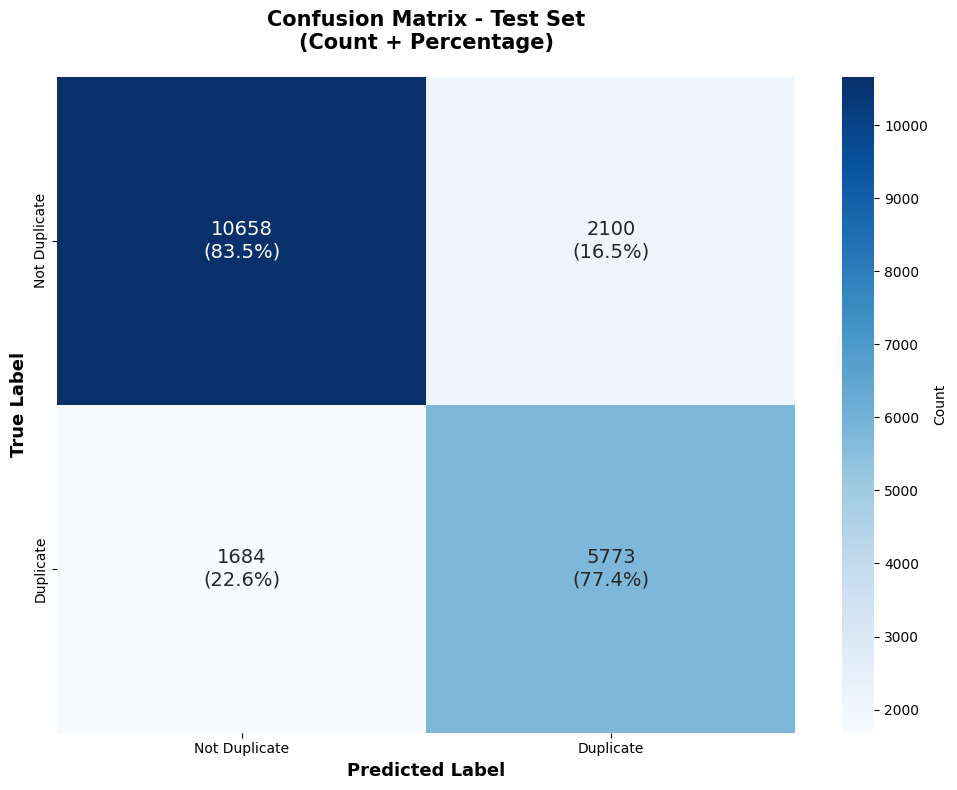

Confusion matrix saved to: confusion_matrix_test_set_20260105_104641.png

                   CLASSIFICATION REPORT                    
               precision    recall  f1-score   support

Not Duplicate     0.8636    0.8354    0.8492     12758
    Duplicate     0.7333    0.7742    0.7532      7457

     accuracy                         0.8128     20215
    macro avg     0.7984    0.8048    0.8012     20215
 weighted avg     0.8155    0.8128    0.8138     20215

                 PER-CLASS DETAILED METRICS                 

Not Duplicate:
  Accuracy:  0.8354 (10658/12758)
  Precision: 0.8636
  Recall:    0.8354
  F1 Score:  0.8492

Duplicate:
  Accuracy:  0.7742 (5773/7457)
  Precision: 0.7333
  Recall:    0.7742
  F1 Score:  0.7532



                   FINAL TEST SET SUMMARY                   
Loss:              0.4495
Accuracy:          0.8128
F1 (Positive):     0.7532
F1 (Macro):        0.8012
F1 (Weighted):     0.8138

Per-Class Metrics:
  Not Duplicate: Acc=0.8354, P=0.8636, R=0.

In [21]:
# Final evaluation on test set for SST-2

import os
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, f1_score, classification_report, precision_recall_fscore_support


def final_evaluation(model, dataloader, split_name, class_names=None, device=None):
    """
    Comprehensive evaluation function for final reporting on SST-2 dataset.
    
    Args:
        model: PyTorch model in evaluation mode.
        dataloader: PyTorch DataLoader with input_ids, token_type_ids, labels, attention_mask.
        split_name (str): Name of the dataset split (e.g., "Test", "Validation").
        class_names (list): List of class names (e.g., ["Negative", "Positive"]). 
                           Defaults to None, using numeric labels if not provided.
        device: Torch device (e.g., torch.device("cuda")). If None, uses model's device.
    
    Returns:
        dict: Metrics including loss, accuracy, F1 scores, confusion matrix, and per-class metrics.
    """
    if device is None:
        device = next(model.parameters()).device
    
    if class_names is None:
        class_names = ["Negative", "Positive"]  # Default for binary classification
    
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0
    num_examples = 0
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc=f"Evaluating {split_name}", leave=False):
            # Move batch to device
            input_ids = batch["input_ids"].to(device)
            segment_ids = batch["token_type_ids"].to(device)
            labels = batch["labels"].to(device)
            attention_mask = batch["attention_mask"].to(device).bool()
            
            # Forward pass with autocast
            with torch.autocast(device_type=device, dtype=torch.bfloat16):
                logits, loss = model(input_ids, token_type_ids=segment_ids, attention_mask=attention_mask, labels=labels)
            
            # Compute predictions
            preds = torch.argmax(logits, dim=-1)
            
            # Track predictions and labels
            batch_size = input_ids.size(0)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
            total_loss += loss.item() * batch_size
            num_examples += batch_size
    
    # Convert to numpy arrays for sklearn
    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    
    # Calculate basic metrics
    correct = np.sum(y_true == y_pred)
    accuracy = correct / len(y_true)
    avg_loss = total_loss / num_examples  # Weighted average by batch size
    
    # Calculate F1 scores
    f1_binary = f1_score(y_true, y_pred, average='binary')  # For positive class
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')
    
    # Calculate precision, recall, F1 per class
    precision, recall, f1_per_class, support = precision_recall_fscore_support(
        y_true, y_pred, average=None, labels=[0, 1]
    )
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Per-class metrics
    per_class_metrics = {}
    for cls_idx, cls_name in enumerate(class_names):
        cls_indices = np.where(y_true == cls_idx)[0]
        cls_correct = np.sum(y_pred[cls_indices] == y_true[cls_indices])
        cls_acc = cls_correct / len(cls_indices) if len(cls_indices) > 0 else 0
        per_class_metrics[cls_name] = {
            "accuracy": cls_acc,
            "precision": precision[cls_idx],
            "recall": recall[cls_idx],
            "f1": f1_per_class[cls_idx],
            "correct": int(cls_correct),
            "total": len(cls_indices)
        }
    
    # Print metrics
    print(f"\n{'='*60}")
    print(f"{split_name} EVALUATION RESULTS".center(60))
    print(f"{'='*60}")
    print(f"Loss: {avg_loss:.4f}")
    print(f"Accuracy: {accuracy:.4f} ({correct}/{len(y_true)})")
    print(f"F1 Score (Positive): {f1_binary:.4f}")
    print(f"F1 Score (Macro): {f1_macro:.4f}")
    print(f"F1 Score (Weighted): {f1_weighted:.4f}")
    
    # Enhanced confusion matrix visualization
    print(f"\n{'='*60}")
    print("CONFUSION MATRIX VISUALIZATION".center(60))
    print(f"{'='*60}")
    
    timestamp = time.strftime("%Y%m%d_%H%M%S")
    plt.figure(figsize=(10, 8))
    
    # Calculate percentages
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    # Create custom annotations with count + percentage
    annotations = []
    for i in range(cm.shape[0]):
        row = []
        for j in range(cm.shape[1]):
            row.append(f'{cm[i,j]}\n({cm_percent[i,j]:.1f}%)')
        annotations.append(row)
    
    sns.heatmap(cm, annot=annotations, fmt='', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'}, annot_kws={'fontsize': 14})
    plt.xlabel('Predicted Label', fontsize=13, fontweight='bold')
    plt.ylabel('True Label', fontsize=13, fontweight='bold')
    plt.title(f'Confusion Matrix - {split_name}\n(Count + Percentage)', 
              fontsize=15, fontweight='bold', pad=20)
    plt.tight_layout()
    
    plot_filename = f'confusion_matrix_{split_name.lower().replace(" ", "_")}_{timestamp}.png'
    plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Confusion matrix saved to: {plot_filename}")
    
    # Print classification report
    print(f"\n{'='*60}")
    print("CLASSIFICATION REPORT".center(60))
    print(f"{'='*60}")
    report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
    print(report)
    
    # Print per-class detailed metrics
    print(f"{'='*60}")
    print("PER-CLASS DETAILED METRICS".center(60))
    print(f"{'='*60}")
    for cls_name, stats in per_class_metrics.items():
        print(f"\n{cls_name}:")
        print(f"  Accuracy:  {stats['accuracy']:.4f} ({stats['correct']}/{stats['total']})")
        print(f"  Precision: {stats['precision']:.4f}")
        print(f"  Recall:    {stats['recall']:.4f}")
        print(f"  F1 Score:  {stats['f1']:.4f}")
    
    print(f"\n{'='*60}\n")
    
    # Return comprehensive metrics
    return {
        "loss": avg_loss,
        "accuracy": accuracy,
        "f1_binary": f1_binary,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "confusion_matrix": cm.tolist(),
        "per_class_metrics": per_class_metrics
    }


# Load the saved model weights
# Load the saved model weights
print("Loading best model...")
model = BertForNLI(num_labels=2)  # Initialize model with the same config
model.load_state_dict(torch.load("best_model.pt"))  # Load the best weights
model = model.to(device)  # Move model to the appropriate device
model.eval()  # Set model to evaluation mode
print("Model loaded successfully!\n")

# Define class names for 
class_names = ["Not Duplicate", "Duplicate"]

# Run final evaluation on test set
print("Starting final evaluation on test set...")
test_metrics = final_evaluation(
    model=model,
    dataloader=test_dataloader,
    split_name="Test Set",
    class_names=class_names,
    device=device
)

# Print summary of key metrics
print("\n" + "="*60)
print("FINAL TEST SET SUMMARY".center(60))
print("="*60)
print(f"Loss:              {test_metrics['loss']:.4f}")
print(f"Accuracy:          {test_metrics['accuracy']:.4f}")
print(f"F1 (Positive):     {test_metrics['f1_binary']:.4f}")
print(f"F1 (Macro):        {test_metrics['f1_macro']:.4f}")
print(f"F1 (Weighted):     {test_metrics['f1_weighted']:.4f}")
print("\nPer-Class Metrics:")
for cls_name, stats in test_metrics['per_class_metrics'].items():
    print(f"  {cls_name}: Acc={stats['accuracy']:.4f}, "
          f"P={stats['precision']:.4f}, R={stats['recall']:.4f}, F1={stats['f1']:.4f}")
print("="*60)

Starting final evaluation on val set...


Evaluating Val Set:   0%|          | 0/79 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:2717: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(



                 Val Set EVALUATION RESULTS                 
Loss: 0.4445
Accuracy: 0.8147 (16469/20215)
F1 Score (Positive): 0.7559
F1 Score (Macro): 0.8033
F1 Score (Weighted): 0.8158

               CONFUSION MATRIX VISUALIZATION               


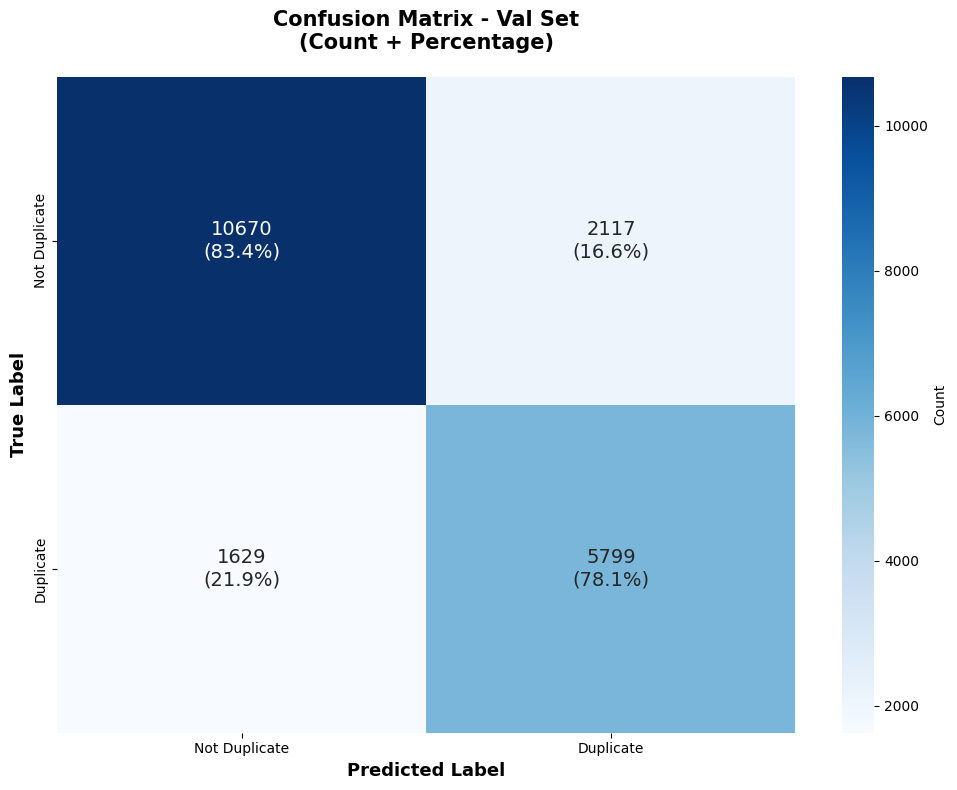

Confusion matrix saved to: confusion_matrix_val_set_20260105_104815.png

                   CLASSIFICATION REPORT                    
               precision    recall  f1-score   support

Not Duplicate     0.8676    0.8344    0.8507     12787
    Duplicate     0.7326    0.7807    0.7559      7428

     accuracy                         0.8147     20215
    macro avg     0.8001    0.8076    0.8033     20215
 weighted avg     0.8180    0.8147    0.8158     20215

                 PER-CLASS DETAILED METRICS                 

Not Duplicate:
  Accuracy:  0.8344 (10670/12787)
  Precision: 0.8676
  Recall:    0.8344
  F1 Score:  0.8507

Duplicate:
  Accuracy:  0.7807 (5799/7428)
  Precision: 0.7326
  Recall:    0.7807
  F1 Score:  0.7559



                   FINAL Val SET SUMMARY                    
Loss:              0.4445
F1 (Positive):     0.7559
F1 (Macro):        0.8033
F1 (Weighted):     0.8158

Per-Class Metrics:
  Not Duplicate: Acc=0.8344, P=0.8676, R=0.8344, F1=0.8507
  Duplicate

In [22]:
# Run final evaluation on val set
print("Starting final evaluation on val set...")
test_metrics = final_evaluation(
    model=model,
    dataloader=val_dataloader,
    split_name="Val Set",
    class_names=class_names,
    device=device
)

# Print summary of key metrics
print("\n" + "="*60)
print("FINAL Val SET SUMMARY".center(60))
print("="*60)
print(f"Loss:              {test_metrics['loss']:.4f}")
print(f"F1 (Positive):     {test_metrics['f1_binary']:.4f}")
print(f"F1 (Macro):        {test_metrics['f1_macro']:.4f}")
print(f"F1 (Weighted):     {test_metrics['f1_weighted']:.4f}")
print("\nPer-Class Metrics:")
for cls_name, stats in test_metrics['per_class_metrics'].items():
    print(f"  {cls_name}: Acc={stats['accuracy']:.4f}, "
          f"P={stats['precision']:.4f}, R={stats['recall']:.4f}, F1={stats['f1']:.4f}")
print("="*60)

best_model.pt				       final_model.pt
confusion_matrix_test_set_20260105_104641.png  training_history.png
confusion_matrix_val_set_20260105_104815.png


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


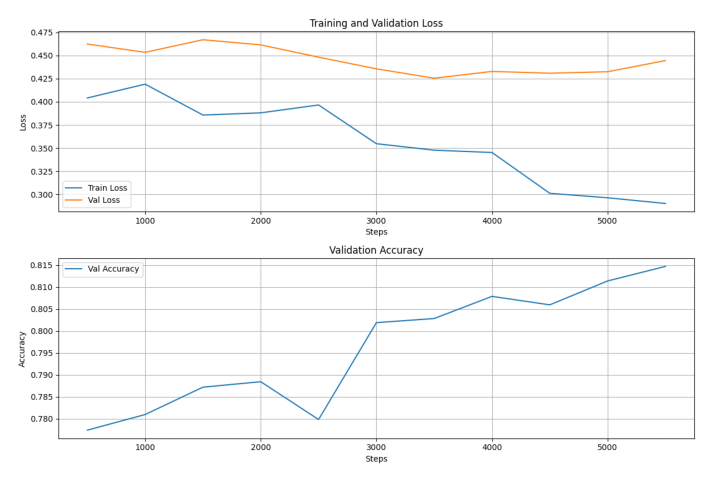

In [23]:
!ls
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('training_history.png')
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis('off')
plt.show()
